# Figures Section 4
Here, the figures corresponding to the section on deviance selection in the final report will be generated

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../'
data_dir_ramani = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f'{root}Generated Data/Final Report/Section 3/'
metadata_dir_ramani = f"{data_dir_ramani}/cell_line_mapping.csv"
data_dir_immune = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
metadata_dir_immune = f"{root}Data/sc_data/cell_types.tsv"
data_dir_bulk = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic' # Importing was not working with relative root+'..' approach, so replace with local data
figure_save_dir = f"{root}Generated Data/Final Report/Section 4/Final Figures/"

In [29]:
### Imports ###
import sys
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, LogLocator
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_calculate_deviance, generate_deviance_heatmap, subset_clr_data, hic_ot_optim, hic_ot_bulk_deviance, generate_umap, generate_clustermap, long_transform, hic_ot_optim_multi
from hicvisutils import hic_vis_region_zoom
from time import perf_counter
from umap import UMAP
from itertools import combinations

In [4]:
### Importing Data ###
clrs_ramani = import_cool_dir(data_dir_ramani)
metadata_df_ramani = pd.read_csv(metadata_dir_ramani)
clrs_immune = import_cool_dir(data_dir_immune)
metadata_df_immune = pd.read_csv(metadata_dir_immune, sep="\t")
clrs_bulk = import_cool_dir(data_dir_bulk, 1_000_000)

## Panel A
Contact maps to compare immune cell and ramani data.

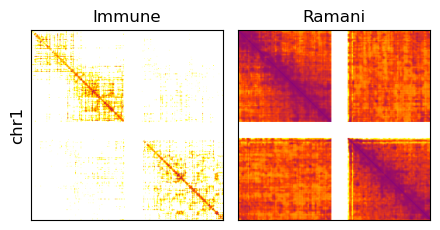

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(4.5, 2.4))

# Immune data
hic_vis_region_zoom(
    clrs_immune[0],
    "chr1",
    cmap="higlass", 
    chr_label="chr1",
    title="Immune",
    ax=ax[0]
)

# Ramani
hic_vis_region_zoom(
    clrs_ramani[0],
    "chr1",
    cmap="higlass", 
    title="Ramani",
    ax=ax[1]
)
plt.tight_layout()
plt.savefig(f"{figure_save_dir}F4A.pdf", bbox_inches='tight')

## Panel B
Density plot of counts (including zeroes) across datasets.

In [10]:
### Helper Function
def compute_histogram(coolers, bins, chunk_size=1_000_000):
    hist = np.zeros(len(bins) - 1)
    total_zeros = 0

    # Constructing histogram
    for clr in coolers:
        n_bins = clr.info["nbins"]
        total_possible = n_bins * (n_bins + 1) // 2
        nnz = clr.info["nnz"]

        total_zeros += (total_possible - nnz)

        # Getting maximum per cooler
        local_max = 0
        for start in range(0, nnz, chunk_size):
            end = min(start + chunk_size, nnz)
            chunk = clr.pixels()[start:end]["count"].values

            if len(chunk):
                local_max = max(local_max, chunk.max())
        
        # Constructing hist with local max
        for start in range(0, nnz, chunk_size):
            end = min(start + chunk_size, nnz)
            chunk = clr.pixels()[start:end]["count"].values

            if len(chunk) == 0:
                continue

            chunk = chunk / local_max
            h, _ = np.histogram(chunk, bins=bins)
            hist += h

    # Add zeroes
    hist[0] += total_zeros

    return hist

In [11]:
### Extracting counts and precomputing histrogram
bins = np.linspace(0, 1, 201)  # 200 bins

bulk_all = compute_histogram(clrs_bulk, bins)
immune_all = compute_histogram(clrs_immune, bins)
ramani_all = compute_histogram(clrs_ramani, bins)

In [13]:
### Zero counts per cooler
print(f"Bulk zeroes per cooler: {bulk_all[0]/len(clrs_bulk)}")
print(f"Immune zeroes per cooler: {immune_all[0]/len(clrs_immune)}")
print(f"Ramani zeroes per cooler: {ramani_all[0]/len(clrs_ramani)}")

Bulk zeroes per cooler: 3703835.1
Immune zeroes per cooler: 4630009.566179012
Ramani zeroes per cooler: 4536376.390322581


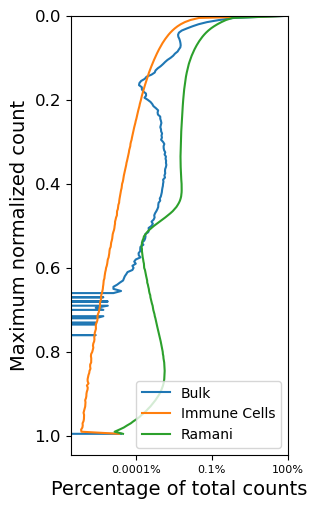

In [48]:
### Figure
labels = ["Bulk", "Immune Cells", "Ramani"]
datasets = [bulk_all, immune_all, ramani_all]

fig, ax = plt.subplots(figsize=(2.8,5.7))

for hist, label in zip(datasets, labels):
    y = hist / hist.sum() * 100
    
    plt.plot(y, bins[:-1], label=label)

plt.legend(loc="best")

plt.ylabel("Maximum normalized count")
plt.xlabel("Percentage of total counts")

plt.xscale("log")

plt.ylim(bottom=0)
ax.invert_yaxis()
plt.xlim(right=100)

plt.xlabel("Percentage of total counts", fontsize=14)
plt.ylabel("Maximum normalized count", fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=8)

# Fewer major ticks
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4))

# Human-readable formatting
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:g}%")
)
plt.savefig(f"{figure_save_dir}F4B.pdf", bbox_inches='tight')

## Panel C
Contact maps showing the deviance value of each contact.

In [129]:
### Extracting deviances
deviances_immune = hic_calculate_deviance(clrs_immune, "chr1")
deviances_ramani = hic_calculate_deviance(clrs_ramani, "chr1")

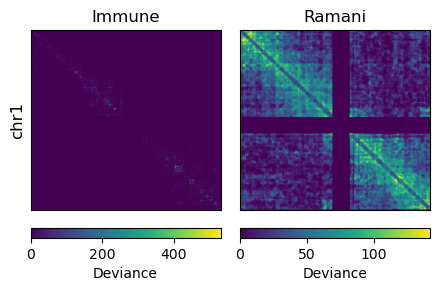

In [133]:
### Figure
fig, ax = plt.subplots(1, 2, figsize=(4.5, 3))
generate_deviance_heatmap(
    deviances_immune,
    True,
    "Immune",
    "chr1",
    ax=ax[0],
    cbar_orient = "horizontal"
)

generate_deviance_heatmap(
    deviances_ramani,
    True,
    "Ramani",
    "chr1",
    ax=ax[1],
    cbar_orient = "horizontal"
)
ax[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{figure_save_dir}F4C.pdf", bbox_inches='tight')

## Panel D
UMAP Immune cell clustering on deviance selection

### Generating Data
TODO:
- Replace later with larger subset

In [88]:
local_save_dir = f"{root}Generated Data/Final Report/Section 4/Panel D/"
immune_panel_d_count = 40
immune_panel_d_top = 500
immune_panel_d_reg_m = 0.1

# Subset
immune_panel_d_subset = subset_clr_data(
    data_dir_immune,
    metadata_df_immune,
    immune_panel_d_count,
    iqr_rule = 1.5
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [27]:
panel_d_results = hic_ot_optim(
    immune_panel_d_subset,
    "chr1",
    "deviance",
    "max",
    top_contacts=immune_panel_d_top,
    unbalanced=immune_panel_d_reg_m
)

# Saving
panel_d_results.to_csv(f'{local_save_dir}immune_deviance_count={immune_panel_d_count}_top={immune_panel_d_top}_reg_m={immune_panel_d_reg_m}_seed=42_iqr=1.5.csv')

  0%|          | 48/40470 [00:03<35:23, 19.03it/s]  /opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 40470/40470 [35:09<00:00, 19.19it/s] 


### UMAP

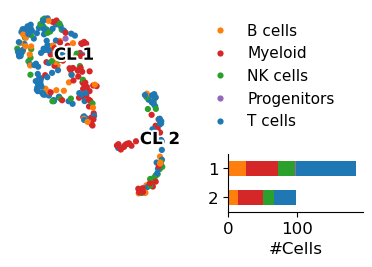

In [89]:
panel_d_results = pd.read_csv(f'{local_save_dir}immune_deviance_count={immune_panel_d_count}_top={immune_panel_d_top}_reg_m={immune_panel_d_reg_m}_seed=42_iqr=1.5.csv', index_col=0)
cell_mapping = {
        "B cells": "B cells",
        "CD4+ T cells": "T cells",
        "CD8+ T cells": "T cells",
        "T cells": "T cells",
        "NK cells": "NK cells",
        "Dendritic cells": "Myeloid",
        "Monocytes": "Myeloid",
        "Neutrophils": "Myeloid",
        "Progenitors": "Progenitors"
    }

panel_d_colors = {
    "T cells": "#1f77b4",
    "B cells": "#ff7f0e",
    "NK cells": "#2ca02c",
    "Myeloid": "#d62728",
    "Progenitors": "#9467bd"
}

panel_d_embed = generate_umap(
    panel_d_results,
    metadata_df_immune,
    group_map=cell_mapping,
    palette=panel_d_colors,
    figsize=(3,2.5),
    bar_size=[0.72, -0.05, 2.6, 0.3]
)
plt.savefig(f"{figure_save_dir}F4D.pdf", bbox_inches='tight')

## Panel E
UMAP Ramani clustering on deviance selection

### Generating Data
TODO:
- Replace later with larger subset

In [85]:
local_save_dir = f"{root}Generated Data/Final Report/Section 4/Panel E/"
ramani_panel_e_count = 100
ramani_panel_e_top = 1500
ramani_panel_e_reg_m = 0.1

ramani_panel_e_subset = subset_clr_data(
    data_dir_ramani,
    metadata_df_ramani,
    ramani_panel_e_count,
    iqr_rule = 1.5,
    type_col="cell_line"
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [6]:
panel_e_results = hic_ot_optim(
    ramani_panel_e_subset,
    "chr1",
    "deviance",
    "max",
    top_contacts=ramani_panel_e_top,
    unbalanced=ramani_panel_e_reg_m
)

# Saving
panel_e_results.to_csv(f'{local_save_dir}ramani_deviance_count={ramani_panel_e_count}_top={ramani_panel_e_top}_reg_m={ramani_panel_e_reg_m}_seed=42_iqr=1.5.csv')

100%|██████████| 50721/50721 [56:58<00:00, 14.84it/s]


### UMAP

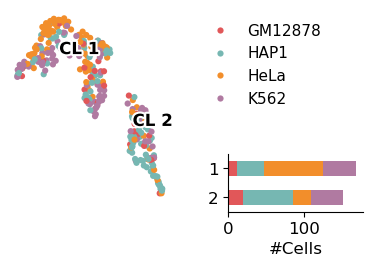

In [87]:
panel_e_results = pd.read_csv(f'{local_save_dir}ramani_deviance_count={ramani_panel_e_count}_top={ramani_panel_e_top}_reg_m={ramani_panel_e_reg_m}_seed=42_iqr=1.5.csv', index_col=0)
panel_e_colors = {
    "GM12878": "#E15759",  
    "HAP1": "#76B7B2",    
    "HeLa": "#F28E2B",    
    "K562": "#B07AA1"      
}
panel_e_embed = generate_umap(
    panel_e_results,
    metadata_df_ramani,
    palette=panel_e_colors,
    type_col="cell_line",
    figsize=(3,2.5),
    bar_size=[0.72, -0.05, 2.6, 0.3]
)
plt.savefig(f"{figure_save_dir}F4E.pdf", bbox_inches='tight')

## Supplementary Figure 1
Clustermaps and times for deviance selection for immune cells and Ramani files

### Helper Functions

In [90]:
### Helper function for importing data ###
def import_data_sup1(dir: str, immune: bool = True) -> dict[str, pd.DataFrame]:
    '''
        Imports unbalanced OT data for section 4, supplementary
        figure 1 as a dictionary with top contacts considered as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        immune : bool
            If true, uses immune cell formatting. Else, uses
            ramani formatting.
            Default = True
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as top
            number of contacts considered
    '''
    # Setting patterns
    if immune:
        pattern = os.path.join(dir, f"IMMUNE_SF1_res=1_top=*_reg_m=0.1_count=2.csv")
        regex = r"IMMUNE_SF1_res=1_top=(?P<top>\d*\.?\d+)_reg_m=0\.1_count=2\.csv"
    else:
        pattern = os.path.join(dir, f"RAMANI_SF1_res=1_top=*_reg_m=0.1_count=3.csv")
        regex = r"RAMANI_SF1_res=1_top=(?P<top>\d*\.?\d+)_reg_m=0\.1_count=3\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            top = match.group("top")
            data_dict[top] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

In [91]:
### Helper function for correspondences ###
def correspondence_matrix(results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    '''
        Takes OT results in a dict given with resolution
        and threshold as keys and returns a dataframe
        giving linear correspondence between all methods.

        Parameters
        ----------
        results : dict[str, pd.DataFrame]
            Results imported as a dict by import_data_sup1.
            
        Returns
        -------
        cor_mat : pd.DataFrame
            Symmetric dataframe giving Pearson r2 between upper
            triangles
    '''
    keys = list(results.keys())
    n    = len(keys)

    # Extract upper triangles
    triags = {}
    for key, df in results.items():
        matrix = df.values
        idx = np.triu_indices(matrix.shape[0], k=1)  # k=1 excludes the diagonal
        triags[key] = matrix[idx].astype(float)
    
    # Correspondence matrix
    cor_mat = pd.DataFrame(np.ones((n, n)), index=keys, columns=keys)

    for key_a, key_b in combinations(keys, 2):
        vec_a = triags[key_a]
        vec_b = triags[key_b]

        r = np.corrcoef(vec_a, vec_b)[0, 1]
        r_squared = r ** 2

        cor_mat.loc[key_a, key_b] = r_squared
        cor_mat.loc[key_b, key_a] = r_squared 
    
    return cor_mat

### Generating Data

In [92]:
### Setting Parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 4/Supplementary Figure 1/"
top_counts = [10, 25, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000]
subset_immune_sf1 = subset_clr_data(
    data_dir_immune,
    metadata_df_immune,
    2
)
subset_ramani_sf1 = subset_clr_data(
    data_dir_ramani,
    metadata_df_ramani,
    3,
    type_col="cell_line"
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x

#### Immune Cells

In [6]:
time_path = f"{local_save_dir}Immune/section4_sf1_IMMUNE.csv"

for top in top_counts:
    print(f"OT FOR RES=1MB, TOP={top}")
    if not os.path.exists(f"{local_save_dir}/Immune/IMMUNE_SF1_res=1_top={top}_reg_m=0.1_count=2.csv"):
        time = perf_counter()

        # OT
        if top < 2000:
            results = hic_ot_optim(
                subset_immune_sf1, 
                "chr1",
                selection="deviance",
                norm="max",
                top_contacts=top,
                unbalanced=0.1)
        else: # Multithreading breaks if OT problem becomes too large
            results=hic_ot_bulk_deviance(
                subset_immune_sf1,
                "chr1",
                top,
                "max",
                0.1
            )

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = "1 Mb"
        top_str = str(top)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[top_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}/Immune/IMMUNE_SF1_res=1_top={top}_reg_m=0.1_count=2.csv")

OT FOR RES=1MB, TOP=10
OT FOR RES=1MB, TOP=25
OT FOR RES=1MB, TOP=50
OT FOR RES=1MB, TOP=100
OT FOR RES=1MB, TOP=250
OT FOR RES=1MB, TOP=500
OT FOR RES=1MB, TOP=750
OT FOR RES=1MB, TOP=1000
OT FOR RES=1MB, TOP=1500


100%|██████████| 153/153 [04:22<00:00,  1.71s/it]


OT FOR RES=1MB, TOP=2000


#### Ramani

In [33]:
time_path = f"{local_save_dir}Ramani/section4_sf1_RAMANI.csv"

for top in top_counts:
    print(f"OT FOR RES=1MB, TOP={top}")
    if not os.path.exists(f"{local_save_dir}/Ramani/RAMANI_SF1_res=1_top={top}_reg_m=0.1_count=3.csv"):
        time = perf_counter()

        # OT
        # if top < 2000:
        results = hic_ot_optim(
            subset_ramani_sf1, 
            "chr1",
            selection="deviance",
            norm="max",
            top_contacts=top,
            unbalanced=0.1)
        # else: # Multithreading breaks if OT problem becomes too large
        #     results=hic_ot_bulk_deviance(
        #         subset_ramani_sf1,
        #         "chr1",
        #         top,
        #         "max",
        #         0.1
        #     )

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = "1 Mb"
        top_str = str(top)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[top_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}/Ramani/RAMANI_SF1_res=1_top={top}_reg_m=0.1_count=3.csv")

OT FOR RES=1MB, TOP=10
OT FOR RES=1MB, TOP=25
OT FOR RES=1MB, TOP=50
OT FOR RES=1MB, TOP=100
OT FOR RES=1MB, TOP=250
OT FOR RES=1MB, TOP=500
OT FOR RES=1MB, TOP=750
OT FOR RES=1MB, TOP=1000
OT FOR RES=1MB, TOP=1500
OT FOR RES=1MB, TOP=2000


100%|██████████| 66/66 [00:05<00:00, 11.22it/s]


OT FOR RES=1MB, TOP=2500
OT FOR RES=1MB, TOP=3000


### Panels A+B
Times

In [110]:
### Getting number of comparisons to convert to time per comparison
results_shape_immune = import_data_sup1(f"{local_save_dir}Immune/")["1500"].shape[0]
n_comparisons_immune = (results_shape_immune ** 2 - results_shape_immune) / 2

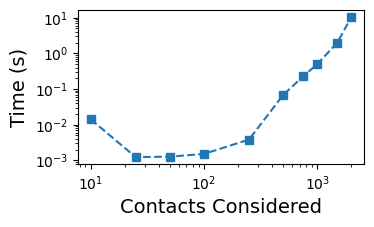

In [111]:
### Panel A
times_immune_sf1 = pd.read_csv(f"{local_save_dir}Immune/section4_sf1_IMMUNE.csv", index_col=0).sort_index(ascending=True)

# Initialize Figure
fig, ax = plt.subplots(figsize=(3.7, 2))

# Figure Balanced
ax.plot(times_immune_sf1["1 Mb"].index, times_immune_sf1["1 Mb"]/n_comparisons_immune, linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Contacts Considered", size=14)
ax.set_ylabel("Time (s)", size=14)
plt.savefig(f"{figure_save_dir}SF11A.pdf", bbox_inches='tight')

In [112]:
### Getting number of comparisons to convert to time per comparison
results_shape_ramani = import_data_sup1(f"{local_save_dir}Ramani/", False)["1500"].shape[0]
n_comparisons_ramani = (results_shape_ramani ** 2 - results_shape_ramani) / 2

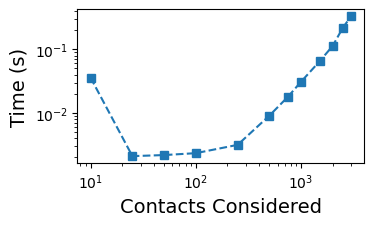

In [113]:
### Panel B
times_ramani_sf1 = pd.read_csv(f"{local_save_dir}Ramani/section4_sf1_RAMANI.csv", index_col=0).sort_index(ascending=True)

# Initialize Figure
fig, ax = plt.subplots(figsize=(3.7, 2))

# Figure Balanced
ax.plot(times_ramani_sf1["1 Mb"].index, times_ramani_sf1["1 Mb"]/n_comparisons_ramani, linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Contacts Considered", size=14)
ax.set_ylabel("Time (s)", size=14)
plt.savefig(f"{figure_save_dir}SF11B.pdf", bbox_inches='tight')

### Panels C+D
Clustermaps

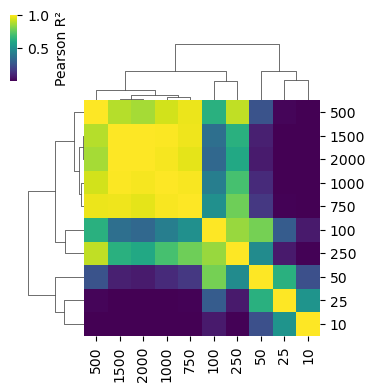

In [114]:
### Panel C
results_immune = import_data_sup1(f"{local_save_dir}Immune/")
cor_mat_immune = correspondence_matrix(results_immune)
g = sns.clustermap(
    cor_mat_immune,
    cmap="viridis", 
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)
plt.savefig(f"{figure_save_dir}SF11C.pdf", bbox_inches='tight')

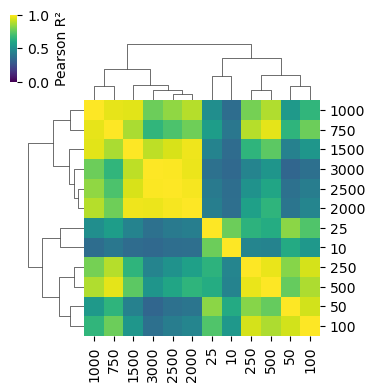

In [115]:
### Panel D
results_ramani = import_data_sup1(f"{local_save_dir}Ramani/", False)
cor_mat_ramani = correspondence_matrix(results_ramani)
g = sns.clustermap(
    cor_mat_ramani,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)
plt.savefig(f"{figure_save_dir}SF11D.pdf", bbox_inches='tight')

## Supplementary Figure 2
Reg_m correspondence and times for deviance selection for immune cells and Ramani files.

### Generating Data

In [116]:
### Setting Parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 4/Supplementary Figure 2/"
reg_m_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
n_cells_immune_sf2 = 2
n_cells_ramani_sf2 = 3
top_immune_sf2 = 750
top_ramani_sf2 = 1500

subset_immune_sf2 = subset_clr_data(
    data_dir_immune,
    metadata_df_immune,
    n_cells_immune_sf2
)
subset_ramani_sf2 = subset_clr_data(
    data_dir_ramani,
    metadata_df_ramani,
    n_cells_ramani_sf2,
    type_col="cell_line"
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x

#### Immune

In [40]:
time_path = f"{local_save_dir}Immune/section4_sf2_IMMUNE.csv"

for reg_m in reg_m_list:
    print(f"OT FOR RES=1MB, TOP={top_immune_sf2}, reg_m={reg_m}")
    if not os.path.exists(f"{local_save_dir}/Immune/IMMUNE_SF2_res=1_top={top_immune_sf2}_reg_m={reg_m}_count=2.csv"):
        time = perf_counter()

        # OT
        results = hic_ot_optim(
            subset_immune_sf2, 
            "chr1",
            selection="deviance",
            norm="max",
            top_contacts=top_immune_sf2,
            unbalanced=reg_m)

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = f"1 Mb, top={top_immune_sf2}"
        reg_m_str = str(reg_m)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[reg_m_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}/Immune/IMMUNE_SF2_res=1_top={top_immune_sf2}_reg_m={reg_m}_count=2.csv")

OT FOR RES=1MB, TOP=750, reg_m=0.001


100%|██████████| 153/153 [00:02<00:00, 53.55it/s] 


OT FOR RES=1MB, TOP=750, reg_m=0.01


100%|██████████| 153/153 [00:00<00:00, 172.14it/s]


OT FOR RES=1MB, TOP=750, reg_m=0.1


...

 78%|███████▊  | 120/153 [02:46<00:48,  1.46s/it]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [03:32<00:00,  1.39s/it]


OT FOR RES=1MB, TOP=750, reg_m=100.0


100%|██████████| 153/153 [03:28<00:00,  1.36s/it]


OT FOR RES=1MB, TOP=750, reg_m=1000.0


 37%|███▋      | 56/153 [01:24<02:52,  1.78s/it]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [04:09<00:00,  1.63s/it]


#### Ramani

In [ ]:
time_path = f"{local_save_dir}Ramani/section4_sf2_RAMANI.csv"

for reg_m in reg_m_list:
    print(f"OT FOR RES=1MB, TOP={top_ramani_sf2}, reg_m={reg_m}")
    if not os.path.exists(f"{local_save_dir}/Ramani/RAMANI_SF2_res=1_top={top_ramani_sf2}_reg_m={reg_m}_count=3.csv"):
        time = perf_counter()

        # OT
        # Multithreading breaks if OT problem becomes too large
        results=hic_ot_bulk_deviance(
            subset_ramani_sf2,
            "chr1",
            top_ramani_sf2,
            "max",
            reg_m
        )

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = f"1 Mb, top={top_ramani_sf2}"
        reg_m_str = str(reg_m)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[reg_m_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}/Ramani/RAMANI_SF2_res=1_top={top_ramani_sf2}_reg_m={reg_m}_count=3.csv")

OT FOR RES=1MB, TOP=1500, reg_m=0.001


100%|██████████| 66/66 [00:11<00:00,  5.97it/s]


OT FOR RES=1MB, TOP=1500, reg_m=0.01


100%|██████████| 66/66 [00:11<00:00,  5.63it/s]


OT FOR RES=1MB, TOP=1500, reg_m=0.1


...

100%|██████████| 66/66 [14:54<00:00, 13.56s/it]


OT FOR RES=1MB, TOP=1500, reg_m=100.0


100%|██████████| 66/66 [15:19<00:00, 13.93s/it]


OT FOR RES=1MB, TOP=1500, reg_m=1000.0


100%|██████████| 66/66 [15:07<00:00, 13.75s/it]


### Importing Helper Function

In [117]:
### Helper function for importing data ###
def import_data_sup2(dir: str, immune: bool = True) -> dict[str, pd.DataFrame]:
    '''
        Imports unbalanced OT data for section 4, supplementary
        figure 2 as a dictionary with top contacts considered as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        immune : bool
            If true, uses immune cell formatting. Else, uses
            ramani formatting.
            Default = True
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as top
            number of contacts considered
    '''
    # Setting patterns
    if immune:
        pattern = os.path.join(dir, f"IMMUNE_SF2_res=1_top={top_immune_sf2}_reg_m=*_count=2.csv")
        regex = rf"IMMUNE_SF2_res=1_top={top_immune_sf2}_reg_m=(?P<reg_m>\d*\.?\d+)_count=2\.csv"
    else:
        pattern = os.path.join(dir, f"RAMANI_SF2_res=1_top={top_ramani_sf2}_reg_m=*_count=3.csv")
        regex = rf"RAMANI_SF2_res=1_top={top_ramani_sf2}_reg_m=(?P<reg_m>\d*\.?\d+)_count=3\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            reg_m = match.group("reg_m")
            data_dict[reg_m] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

### Panels A+B
Times

In [119]:
### Getting number of comparisons to convert to time per comparison
results_shape_immune = import_data_sup2(f"{local_save_dir}Immune/")["0.1"].shape[0]
n_comparisons_immune = (results_shape_immune ** 2 - results_shape_immune) / 2

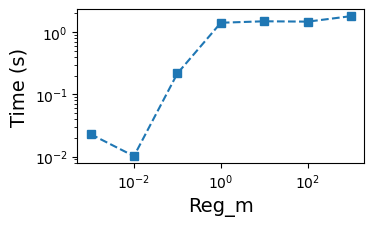

In [124]:
### Panel A
times_immune_sf2 = pd.read_csv(f"{local_save_dir}Immune/section4_sf2_IMMUNE.csv", index_col=0).sort_index(ascending=True)

# Initialize Figure
fig, ax = plt.subplots(figsize=(3.7, 2))

# Figure Balanced
ax.plot(times_immune_sf2[f"1 Mb, top={top_immune_sf2}"].index, times_immune_sf2[f"1 Mb, top={top_immune_sf2}"]/n_comparisons_immune, linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Reg_m", size=14)
ax.set_ylabel("Time (s)", size=14)
plt.savefig(f"{figure_save_dir}SF12A.pdf", bbox_inches='tight')

In [121]:
### Getting number of comparisons to convert to time per comparison
results_shape_ramani = import_data_sup2(f"{local_save_dir}Ramani/", False)["0.1"].shape[0]
n_comparisons_ramani = (results_shape_ramani ** 2 - results_shape_ramani) / 2

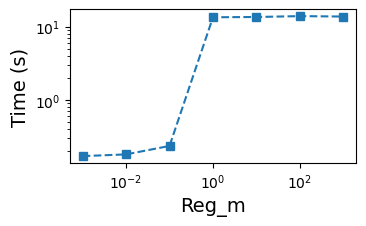

In [123]:
### Panel B
times_ramani_sf2 = pd.read_csv(f"{local_save_dir}Ramani/section4_sf2_RAMANI.csv", index_col=0).sort_index(ascending=True)

# Initialize Figure
fig, ax = plt.subplots(figsize=(3.7, 2))

# Figure Balanced
ax.plot(times_ramani_sf2[f"1 Mb, top={top_ramani_sf2}"].index, times_ramani_sf2[f"1 Mb, top={top_ramani_sf2}"]/n_comparisons_ramani, linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Reg_m", size=14)
ax.set_ylabel("Time (s)", size=14)
plt.savefig(f"{figure_save_dir}SF12B.pdf", bbox_inches='tight')

### Panels C+D
Clustermaps

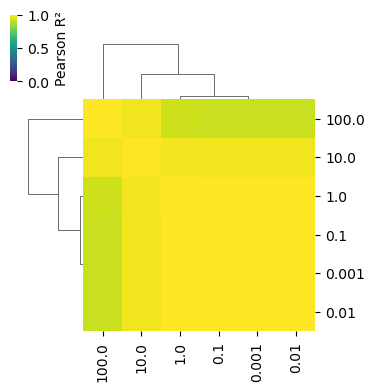

In [125]:
### Panel C
results_immune_sf2 = import_data_sup2(f"{local_save_dir}Immune/")
cor_mat_immune_sf2 = correspondence_matrix(results_immune_sf2)
g = sns.clustermap(
    cor_mat_immune_sf2,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)
plt.savefig(f"{figure_save_dir}SF12C.pdf", bbox_inches='tight')

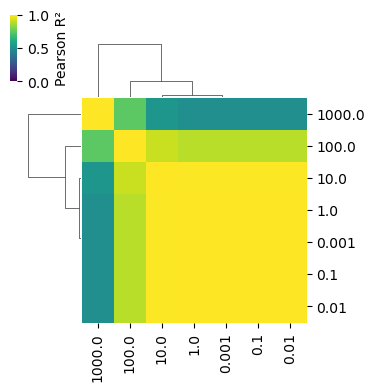

In [126]:
### Panel D
results_ramani_sf2 = import_data_sup2(f"{local_save_dir}Ramani/", False)
cor_mat_ramani_sf2 = correspondence_matrix(results_ramani_sf2)
g = sns.clustermap(
    cor_mat_ramani_sf2,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)
plt.savefig(f"{figure_save_dir}SF12D.pdf", bbox_inches='tight')

## Supplementary Figure 3
Clustermaps for OT data

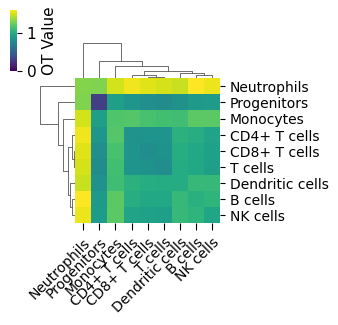

In [127]:
### Immune
immune_sf3 = long_transform(panel_d_results, metadata_df_immune)
generate_clustermap(
    immune_sf3,
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(3.4,3.4),
    cbar_pos=(-0.04, 0.87, 0.02, 0.18),
    textsize=11
)
plt.savefig(f"{figure_save_dir}SF13A.pdf", bbox_inches='tight')

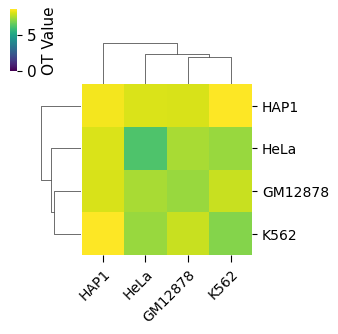

In [128]:
### Ramani
ramani_sf3 = long_transform(panel_e_results, metadata_df_ramani, type_col="cell_line")
generate_clustermap(
    ramani_sf3,
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(3.4,3.4),
    cbar_pos=(-0.04, 0.87, 0.02, 0.18),
    textsize=11
)
plt.savefig(f"{figure_save_dir}SF13B.pdf", bbox_inches='tight')

## Supplementary Figure 4
Log-scaled deviance heatmaps

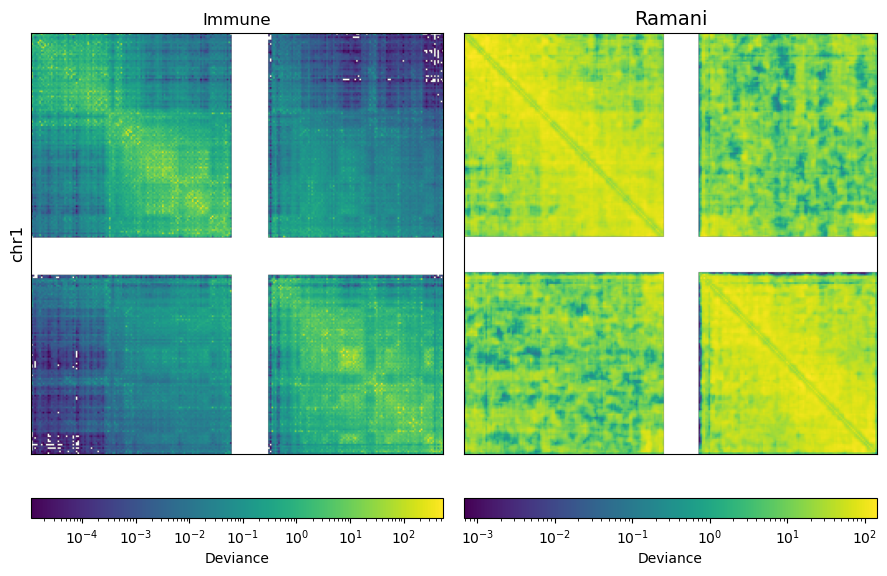

In [137]:
### Figure
fig, ax = plt.subplots(1, 2, figsize=(9, 6))
generate_deviance_heatmap(
    deviances_immune,
    True,
    "Immune",
    "chr1",
    ax=ax[0],
    cbar_orient = "horizontal",
    log_scale=True
)

generate_deviance_heatmap(
    deviances_ramani,
    True,
    "Ramani",
    "chr1",
    ax=ax[1],
    cbar_orient = "horizontal",
    log_scale=True,
    textsize=14
)
ax[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{figure_save_dir}SF14.pdf", bbox_inches='tight')